# Meshing with GMSH 

This tutorial covers the following topics:
- Working with elementary geometrical GMSH entities (points, curves, surfaces, volumes)
- Tagging physically relevant geometrical entities using Physical Groups
- Local mesh refinement using Fields
- Meshing and mesh quality
- Boolean operations
- Using both GMSH's built-in scripting language and the Python GMSH package

### Environment Setup
Adding requirements to the environment so that we can using the Python GMSH API and also visualize using pyvista but without a display. 

In [ ]:
pip install gmsh

In [ ]:
pip install --extra-index-url https://wheels.vtk.org vtk-osmesa

In [1]:
import sys
sys.path.append("/home/qwxdev/.local/lib/python3.12/site-packages")

In [3]:
import gmsh
import numpy as np
# compatibility patch
if not hasattr(np, "bool"):
    np.bool = bool
import matplotlib.pyplot as plt
%matplotlib inline
import pyvista as pv
import meshio 
from IPython.display import Image
import panel as pn
pn.extension('vtk')

<ipython-input-3-e8ef19b6cf66>:4: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if not hasattr(np, "bool"):


If the above packages cannot be found, please try restarting your kernel and run the `sys.path.append()` step and the `import` steps again. 

## Demo 1: A Simple 2D Rectangle

As a first example, we will create a simple 2D rectangular geometry using what GMSH refers to as elementary entities: points, curves, surfaces (later we will use volumes). This example closely follows Tutorial 1 from the GMSH developers. 
https://gmsh.info/doc/texinfo/gmsh.html#t1

Geometries and meshes can be created in GMSH in several different ways. GMSH provides a GUI which users can use directly; this is useful to become familiar with GMSH, but here we will focus on scripting approaches. The first scripting approach involves writing `.geo` files, which are text based and are interpreted by GMSH to create geometries and meshes. The second scripting approach is by using the `gmsh` package directly in Python. This allows for more programmatical interactions with GMSH entities.  

### Using a `.geo` file

Let's check out what is in the file `tutorial_1.geo` that lives in this directory. You can open it up yourself, or print it using the cell below. 

In [5]:
with open('tutorial_1.geo', 'r') as file:
    content = file.read()
    print(content)


// Define a variable. This will be used as the target cell size in the mesh
h_min = 1e-2;

// Define points
Point(1) = {0, 0, 0, h_min};
Point(2) = {.3, 0,  0, h_min};
Point(3) = {.3, .2, 0, h_min};
Point(4) = {0,  .2, 0, h_min};

// Define lines, a type of curve, which is one of GMSH's elementary entities.
// Lines are directed, from the start point to the end point. 
Line(1) = {1, 2};
Line(2) = {3, 2};
Line(3) = {3, 4};
Line(4) = {4, 1};

// The third elementary entity is the surface
// In order to define a surface (the third elementary entity), 
// we must first define a curve loop. The curve loop is sensitive 
// to the directionality of the lines.
Curve Loop(1) = {4, 1, -2, 3};

// We can then define the surface as a list of curve loops 
Plane Surface(1) = {1};

// Elementary geometrical entities can be assigned to physically meaningful groups
// To do this, we define "physical groups", such as physical points, physical curves, 
// physical surfaces, or physical volumes. 

Physic

---

We can use GMSH to create the mesh for this geometry. 

The line of code below runs the GMSH executable on the `.geo` script, while specifying that a 2D mesh should be created. 

In [6]:
!gmsh -2 tutorial_1.geo

Info    : Running 'gmsh -2 tutorial_1.geo' [Gmsh 4.11.1, 1 node, max. 1 thread]
Info    : Started on Mon Jun  8 13:51:37 2026
Info    : Reading 'tutorial_1.geo'...
Info    : Done reading 'tutorial_1.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000321707s, CPU 0.000136s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0157201s, CPU 0.015574s)
Info    : 752 nodes 1506 elements
Info    : Writing 'tutorial_1.msh'...
Info    : Done writing 'tutorial_1.msh'
Info    : Stopped on Mon Jun  8 13:51:37 2026 (From start: Wall 0.0243456s, CPU 0.111104s)


The file `tutorial_1.msh` should have appeared in this directory. 

Now we can take a look at the saved mesh using a Python package called PyVista. 

First we convert the `.msh` file to `.vtu` file format to enable easy visualization in this Python environment. 

In [7]:
msh = meshio.read("tutorial_1.msh")
msh.write("tutorial_1.vtu");

Info: VTU format cannot write cell_sets. Converting them to cell_data...

Warning: 28 cells are not part of any cell set. Using default value -1.

In [8]:
import panel as pn
pn.extension('vtk')

We can load this mesh from the vtu file using pyvista, to investigate and visualize it. 

In [9]:
mesh = pv.read("tutorial_1.vtu")

print(mesh)
print('mesh contains physical tags:', np.unique(mesh["gmsh:physical"]))

UnstructuredGrid (0x15550bd6e020)
  N Cells:    1472
  N Points:   752
  X Bounds:   0.000e+00, 3.000e-01
  Y Bounds:   0.000e+00, 2.000e-01
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   4
mesh contains physical tags: [ 5 66]


In [10]:
mesh.array_names

['gmsh:dim_tags',
 'gmsh:physical',
 'gmsh:geometrical',
 'gmsh:bounding_entities']

In [11]:
fname = "tutorial_1.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 2}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh, style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)
pl.add_mesh(mesh.threshold(value=(4,6), scalars="gmsh:physical"), \
            style='wireframe', line_width=3, scalars="gmsh:physical", scalar_bar_args=sargs)
pl.enable_parallel_projection()
pl.camera_position = 'xy'
pl.screenshot(fname);

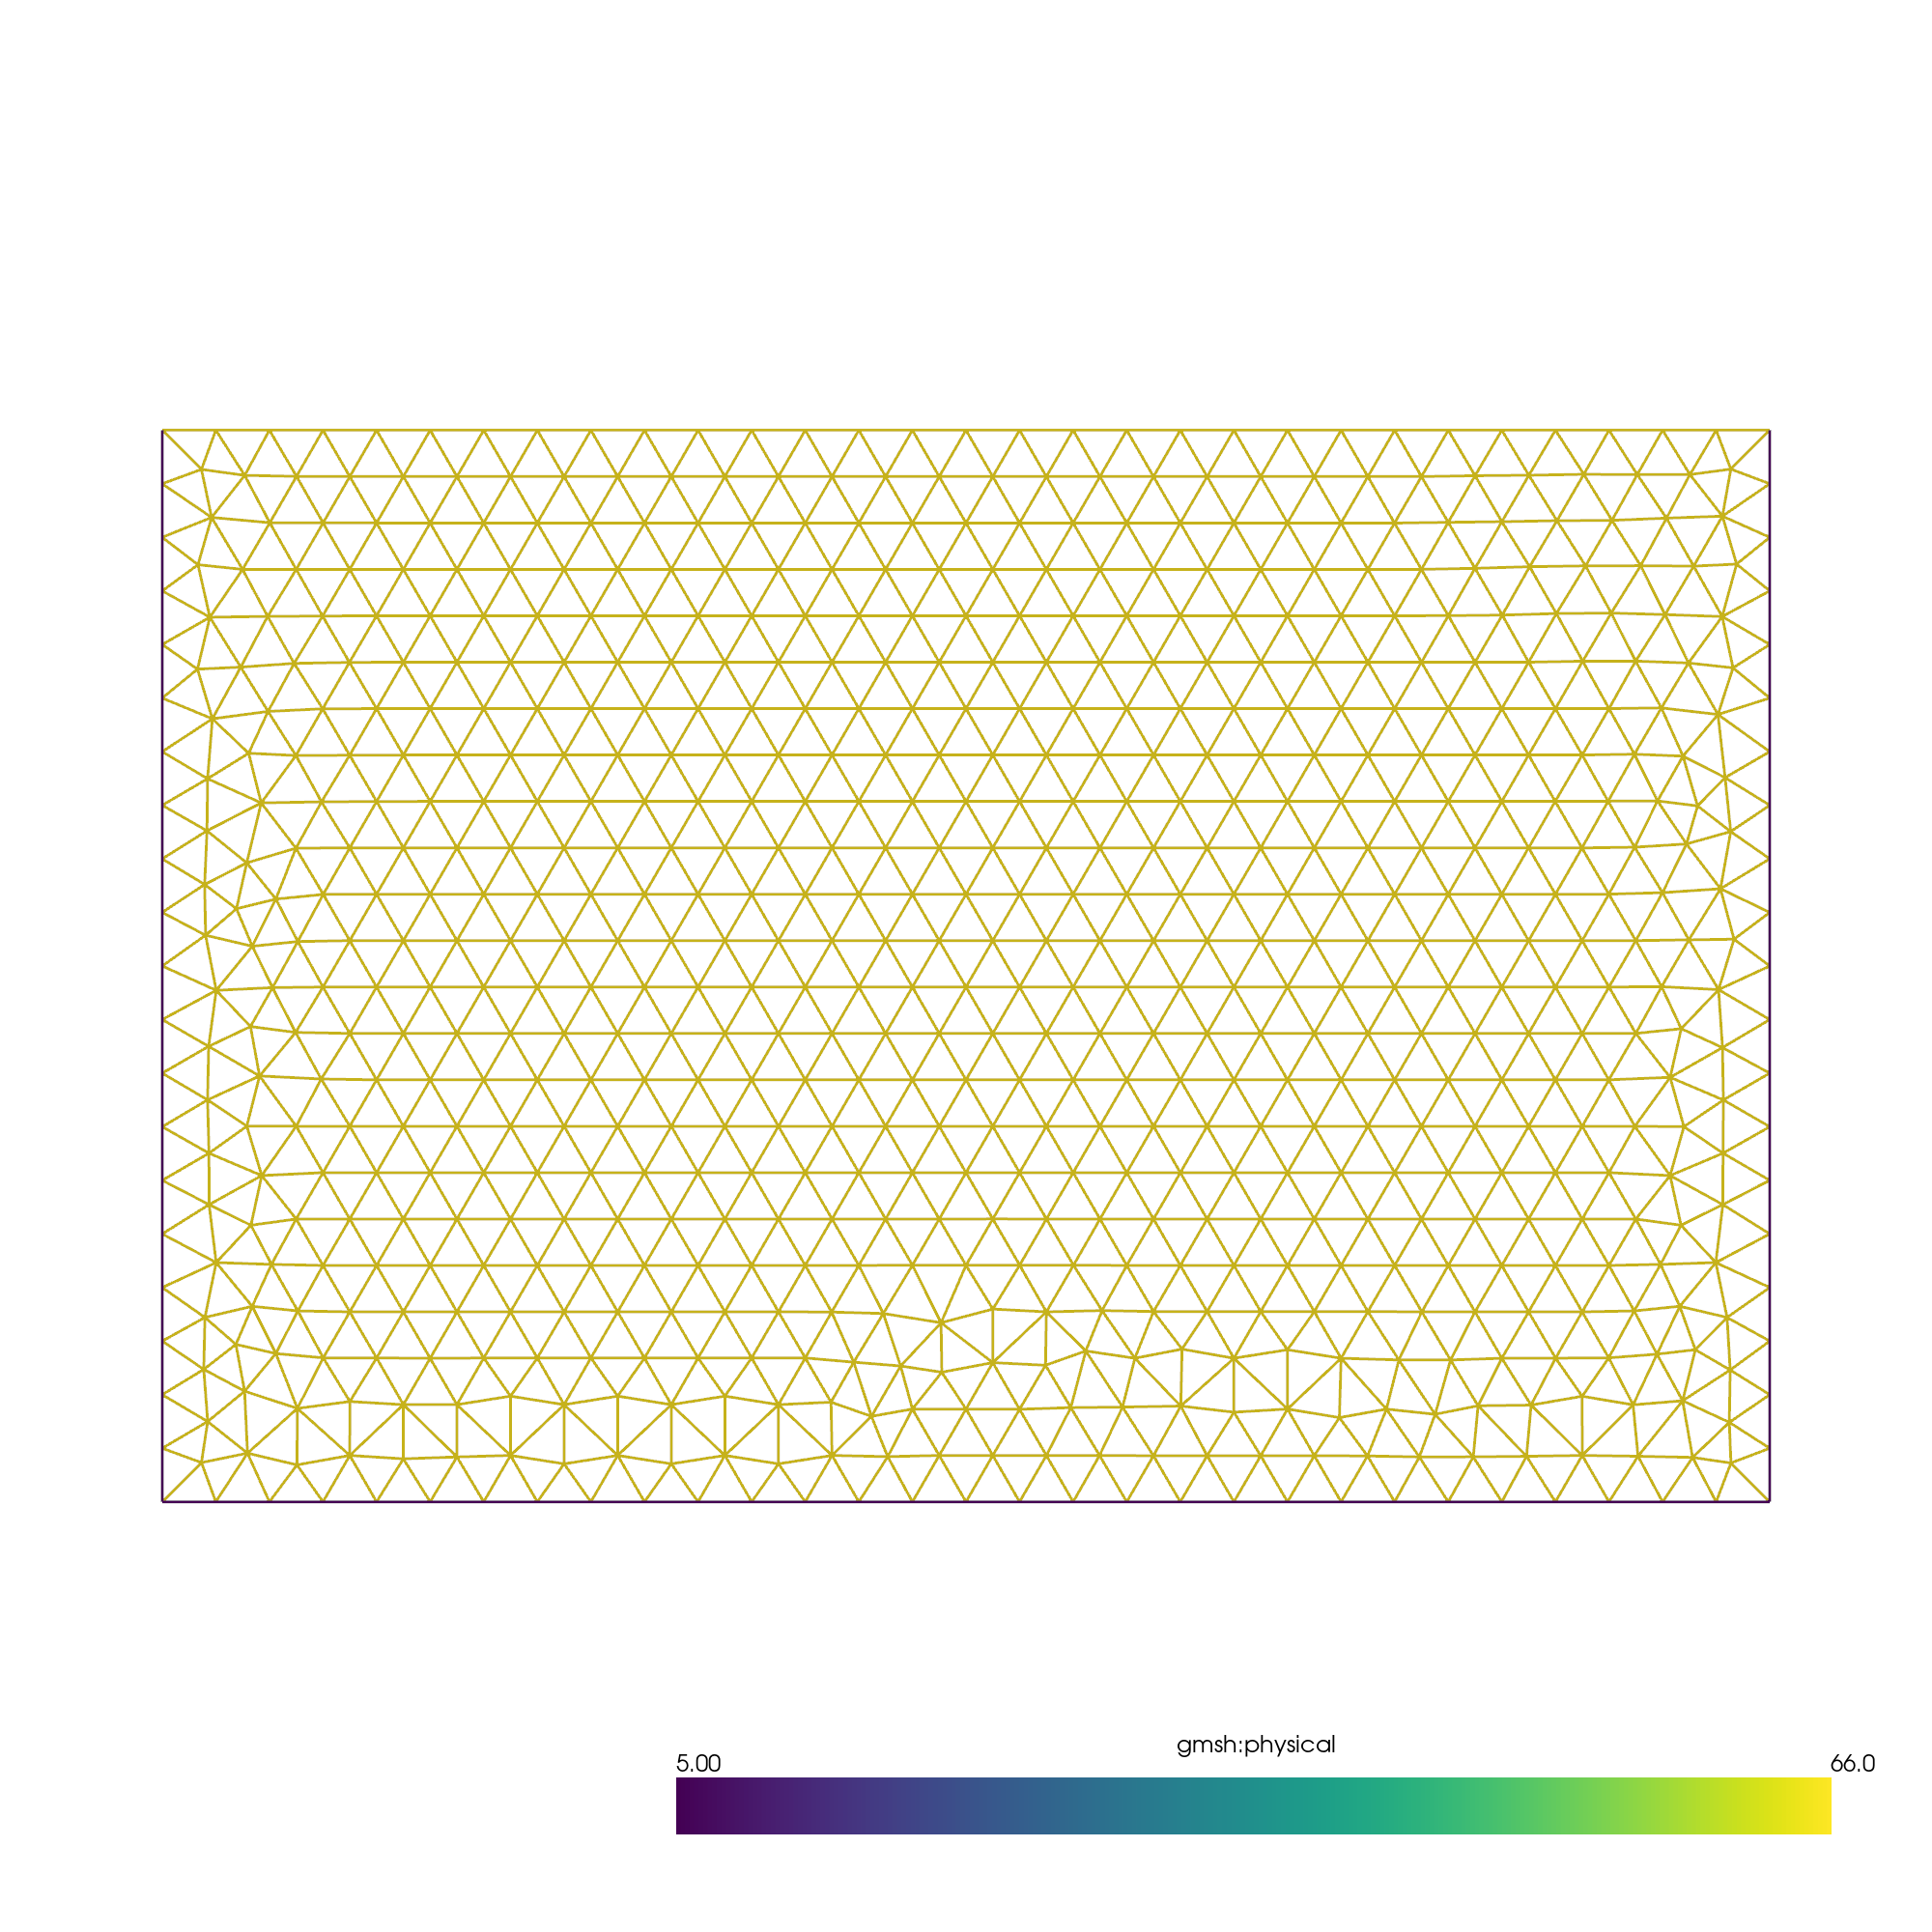

In [12]:
from IPython.display import Image
Image(filename='./tutorial_1.png')

### Demo 1, but using the Python API 

The Python code below uses the `gmsh` Python package to create the same geometry and mesh as we did above with the `.geo` file. 

Using Python code to create geometries in GMSH offers some advantages. If many points must be placed in the domain, we can handle those points using arrays. If we wish to load data from other files, perform any calculations on the data, and then add them to our geometry, we can do this naturally and programmatically.

In [13]:
import gmsh

First, we initialize the GMSH model. The model name is entirely up to the user. Throughout this demo, we will be adding elementary entities to this model. Since GMSH refers to entities using their tags, it does not allow us to add an entitity of the same kind (point, curve, etc.) with the same tag if that tag is already used. So, if you encounter an error along the lines of: `"Exception: GEO point with tag 1 already exists"`, please return to the cell below and re-run it to re-initialize the model from scratch. 

In [14]:
gmsh.initialize()

gmsh.model.add("tutorial_1")

We can also define any variables which may be helpful. 

In [15]:
lc = 1e-2

We can add points by calling `addPoint`, with the syntax (x, y, z, meshSize, tag). 

In [16]:
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)
gmsh.model.geo.addPoint(.3, 0, 0, lc, 2)
gmsh.model.geo.addPoint(.3, .2, 0, lc, 3);

We can also omit the tag, allow GMSH to use the next available tag number to refer to the point, and capture the output tag to use later when referring to that point. 

In [17]:
p4 = gmsh.model.geo.addPoint(0, .2, 0, lc)
print('Point created with tag:', p4)

Point created with tag: 4


Next, we create lines using the function `addLine`, with the syntax `(startTag, endTag, tag)`.

In [18]:
gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(3, 2, 2)
gmsh.model.geo.addLine(3, p4, 3)
gmsh.model.geo.addLine(4, 1, p4)

4

GMSH does consider lines to be directed, so the ordering of the start and end points matters when joining up the lines in a Curve Loop. You can add a `-` sign in front of a Line's tag to reverse its direction.

In [19]:
CL = gmsh.model.geo.addCurveLoop([4, 1, -2, 3], 111)
print('Curve Loop created with tag:', CL)

Curve Loop created with tag: 111


We have captured the tag of the Curve Loop in the variable CL. We can pass that variable to `addPlaneSurface` to indicate that GMSH should create a surface using that Curve Loop. 

In [20]:
PS = gmsh.model.geo.addPlaneSurface([CL], 1)
print('Plane Surface created with tag:', PS)

Plane Surface created with tag: 1


It is a good idea to periodically `synchronize` your model. This means that the elementary entities you have defined (which GMSH calls CAD entities) get synchronized with the internal model. This is necessary for certain operations or manipulations to be performed, and for a mesh to be generated. 

In [21]:
gmsh.model.geo.synchronize()

We can also assign elementary geometrical entities to physically meaningful groups. To do this, we define "physical groups", such as physical points, physical curves, physical surfaces, or physical volumes. For demontration purposes, let's tag the Lines with tags 1, 2, and 4 as a Physical Curve with tag 5. Also, let's tag the Plane Surface as a Physical Surface with tag 66. 

In [22]:
gmsh.model.addPhysicalGroup(1, [1, 2, 4], 5)
gmsh.model.addPhysicalGroup(2, [1], 66, name="My surface")

66

Finally, we can generate a 2D mesh, write it to file, and finalize our GMSH model. 

In [23]:
gmsh.model.mesh.generate(2)

gmsh.write("t1.msh")

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000354188s, CPU 0.000358s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0215508s, CPU 0.017961s)
Info    : 752 nodes 1506 elements
Info    : Writing 't1.msh'...
Info    : Done writing 't1.msh'


In [24]:
import pyvista as pv
import meshio 

In [25]:
msh = meshio.read("t1.msh")
msh.write("t1.vtu");

Info: VTU format cannot write cell_sets. Converting them to cell_data...

Warning: 28 cells are not part of any cell set. Using default value -1.

In [26]:
mesh = pv.read("t1.vtu")

print(mesh)
print('mesh contains physical tags:', np.unique(mesh["gmsh:physical"]))

UnstructuredGrid (0x15550bfc09a0)
  N Cells:    1472
  N Points:   752
  X Bounds:   0.000e+00, 3.000e-01
  Y Bounds:   0.000e+00, 2.000e-01
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   4
mesh contains physical tags: [ 5 66]


In [27]:
fname = "t1.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 2}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh, style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)
pl.add_mesh(mesh.threshold(value=(4,6), scalars="gmsh:physical"), \
            style='wireframe', line_width=3, scalars="gmsh:physical", scalar_bar_args=sargs)
pl.enable_parallel_projection()
pl.camera_position = 'xy'
pl.screenshot(fname);

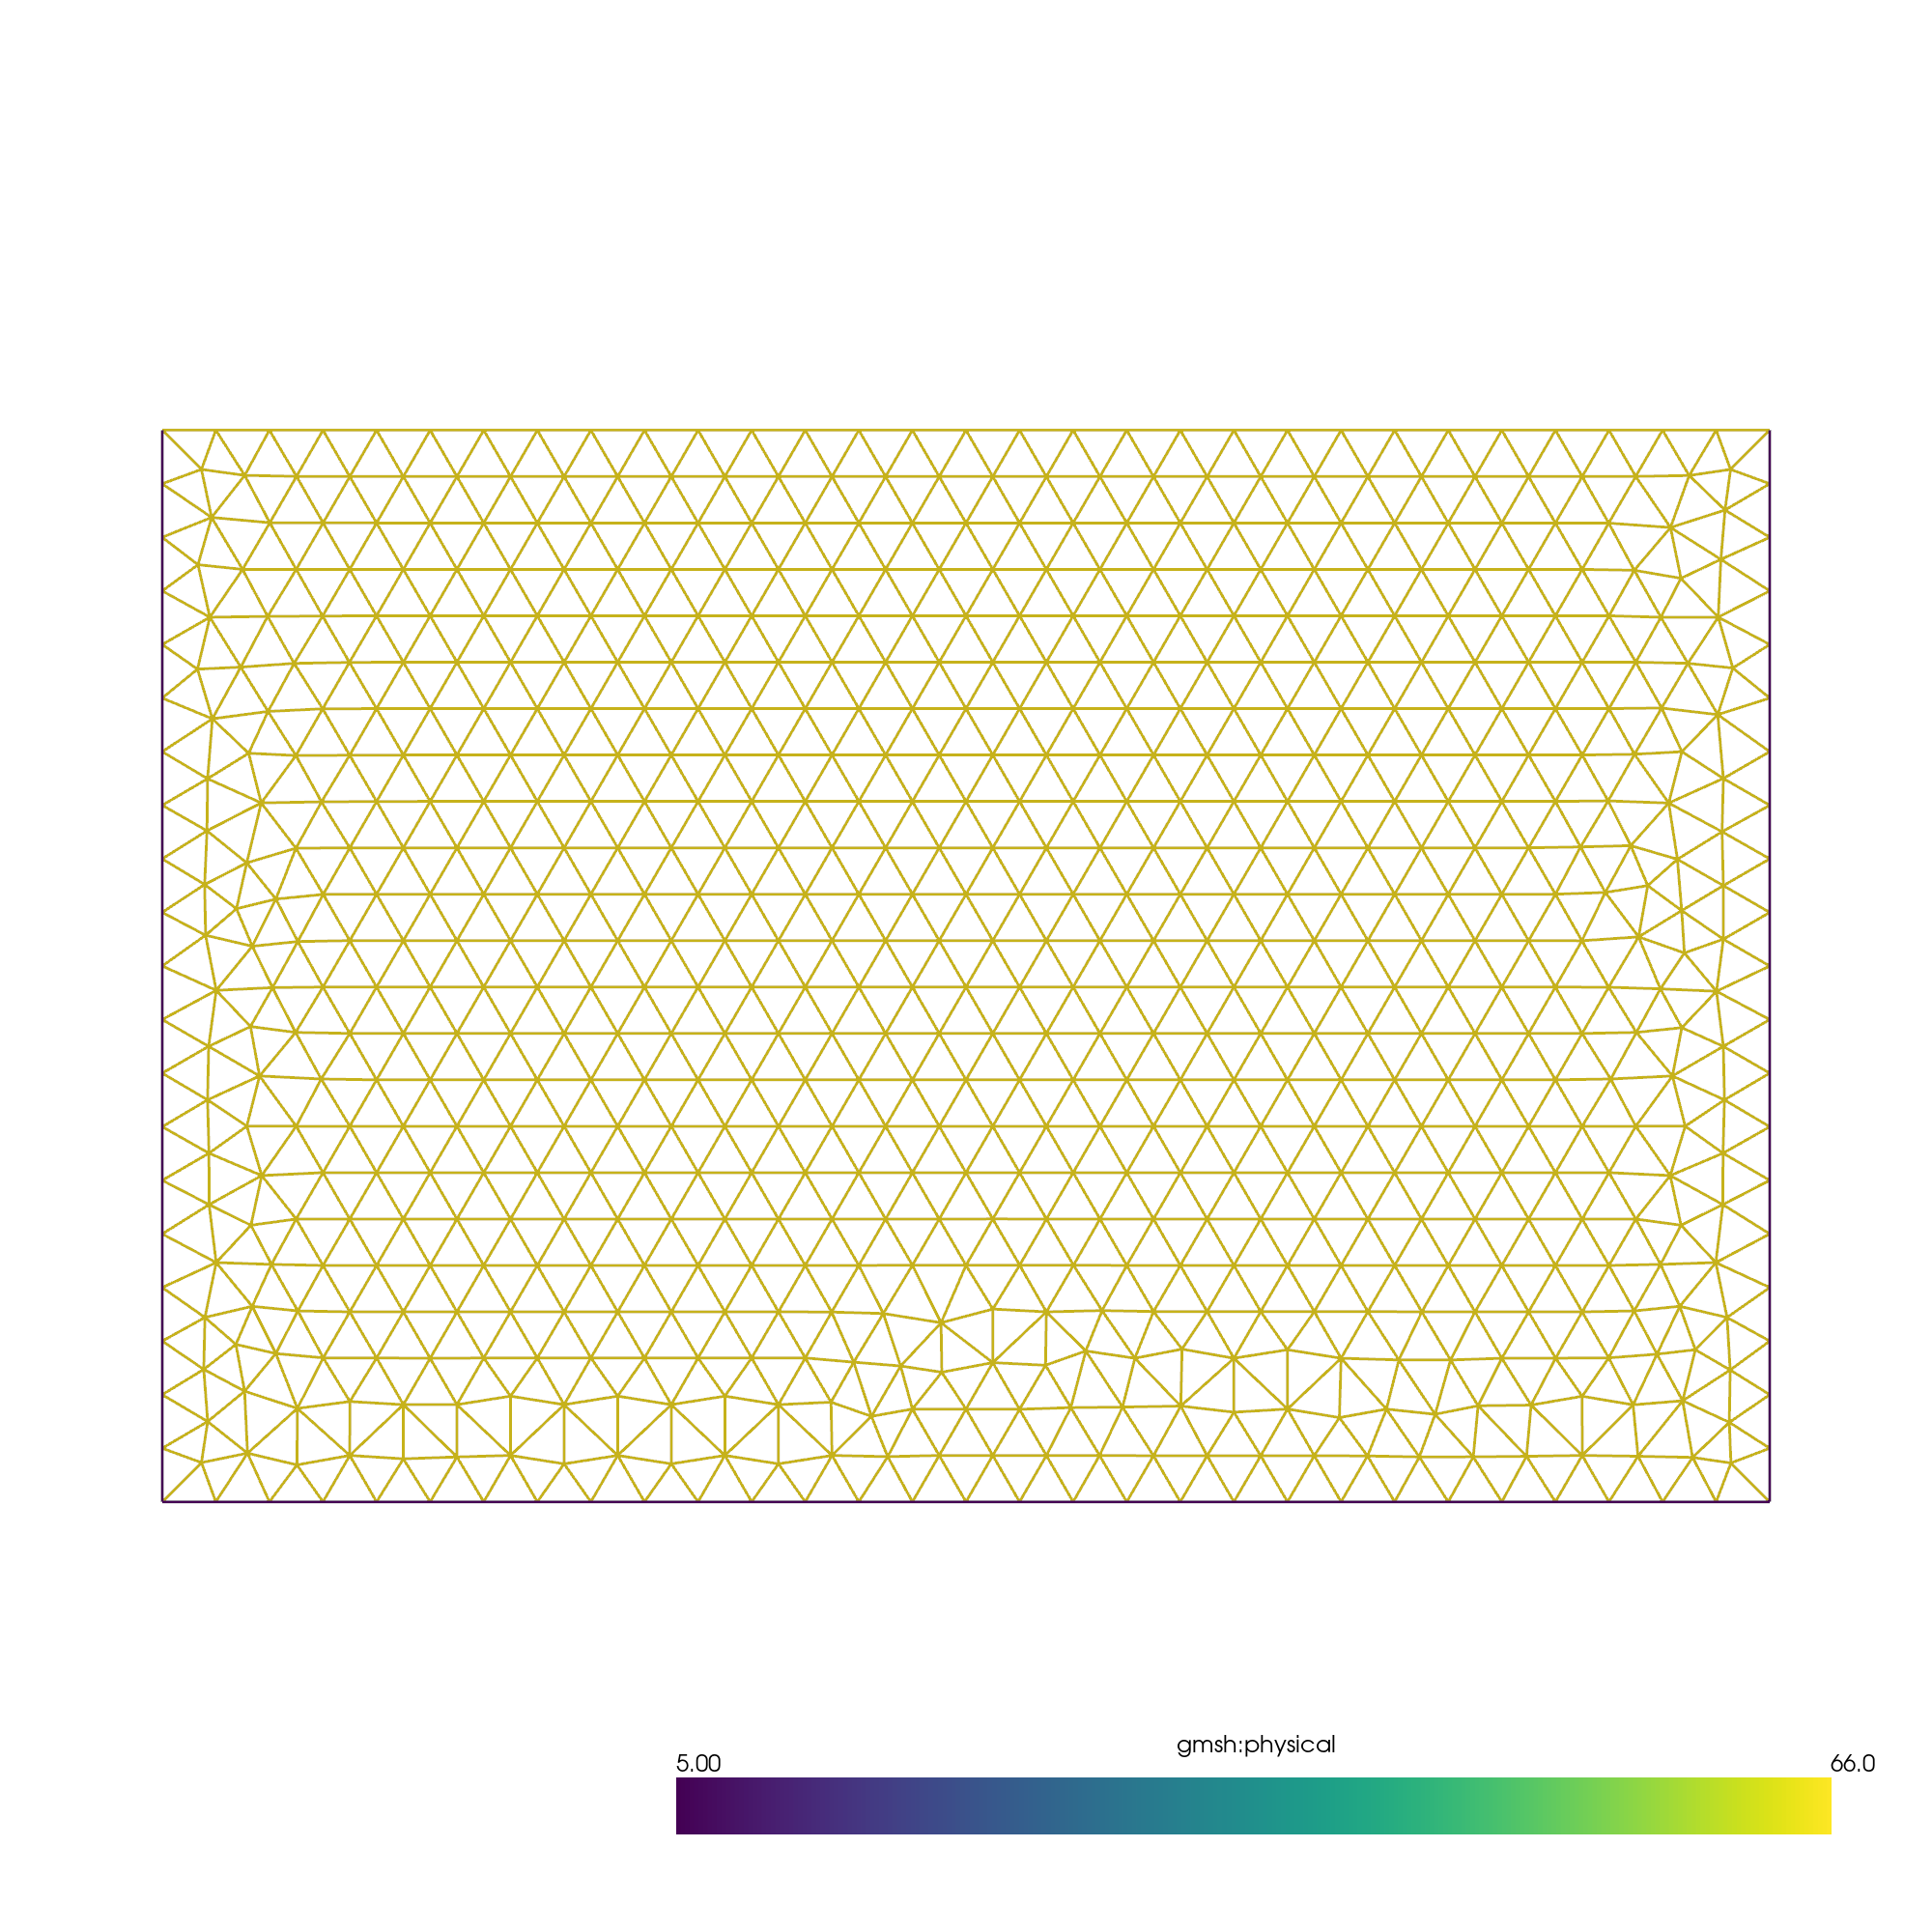

In [28]:
from IPython.display import Image
Image(filename='./t1.png')

## Demo 2: a 3D domain with an embedded fault

This demonstration shows how to use Python and GMSH to create the mesh for the TPV 13-3D benchmark exercise. The geometry required for this benchmark is a box with a 60° dipping rectangular fault plane. The mesh must explictly include a nucleation patch at the hypocenter, and geometrical entities must have physical tags that will allow SeisSol to set the correct boundary conditions.

Since this example requires a Boolean fragments operation to embed the fault in a volume, we must use the OpenCascade kernel in GMSH instead of the built-in geometry kernel we used previously. We access this by using `gmsh.model.occ` instead of `gmsh.model.geo`. 

In [29]:
gmsh.initialize()

gmsh.model.add("tpv12_13")

We begin by defining variables to set target mesh sizes in different parts of the domain, as well as the fault dip angle. 

In [30]:
h_domain = 5e3 # Mesh spacing within model domain
h_fault = 1000.0 # Mesh spacing on the fault
h_nucl = 500.0 # Refined mesh spacing within the fault nucleation patch

dip = 60.0 # Fault dip
dip_rad = dip*np.pi/180.;

Next we define some variables for the fault dimensions, the nucleation patch, and the domain size.  

In [31]:
l_f = 30e3 # Length of the fault
w_f = 15e3 # Width of the fault (along-dip)

x_n = 0e3 # hypocenter fault-local coordinate
z_n = -12e3 # hypocenter depth along-dip

l_n = 3e3 # nucleation patch length
w_n = 3e3 # nucleation patch width 

# domain size: 3-4 times the fault’s dimension
X0 = -45e3
X1 = -X0
Y0 = -36e3
Y1 = -Y0
Z0 = -42e3

In [32]:
domain = gmsh.model.occ.addBox(X0, Y0, Z0, X1-X0, Y1-Y0, -Z0)

In [33]:
fault = gmsh.model.occ.addRectangle(-l_f/2, -w_f, 0, l_f, w_f)

nucl = gmsh.model.occ.addRectangle(x_n - l_n/2, z_n - w_n/2, 0, l_n, w_n)

gmsh.model.occ.synchronize()

In [34]:
gmsh.model.occ.rotate([(2, fault)], 0, 0, 0, 1, 0, 0, dip_rad)
gmsh.model.occ.rotate([(2, nucl)], 0, 0, 0, 1, 0, 0, dip_rad)

In [35]:
tags_out, map_out = gmsh.model.occ.fragment([(2,fault), (2, nucl)], [(3, domain)], removeObject=True, removeTool=True)

In [36]:
eps = 1e-3;
fault_final = gmsh.model.occ.getEntitiesInBoundingBox(-l_f/2-eps, -w_f-eps, -w_f-eps, l_f/2+eps, w_f+eps, w_f+eps)
gmsh.model.occ.synchronize()
fault_final_tags = [tag for dim, tag in fault_final if dim > 1]
print(f"Surfaces found inside the bounding box: {fault_final_tags}")

Surfaces found inside the bounding box: [8, 9]


In [37]:
free_surface = gmsh.model.occ.getEntitiesInBoundingBox(X0-eps, Y0-eps, -eps, X1+eps, Y1+eps, eps)
free_surface_tag = [tag for dim, tag in free_surface if dim > 1]
print(f"Free surface has tag: {free_surface_tag}")

Free surface has tag: [12]


In [38]:
surfaces = gmsh.model.getEntities(dim=2)
absorbing_tags = [tag for dim, tag in surfaces if (tag not in fault_final_tags) and (tag not in free_surface_tag)]
print(f"Absorbing boundary surfaces: {absorbing_tags}")

Absorbing boundary surfaces: [10, 11, 13, 14, 15]


In [39]:
bnd_domain = gmsh.model.getBoundary([(3, domain)], recursive=True)
gmsh.model.mesh.setSize(bnd_domain, h_domain)

bnd_fault = gmsh.model.getBoundary([(2,tag) for tag in fault_final_tags], recursive=True)
gmsh.model.mesh.setSize(bnd_fault, h_fault)

bnd_nucl = gmsh.model.getBoundary([(2, nucl)], recursive=True)
gmsh.model.mesh.setSize(bnd_nucl, h_nucl)

Now we use physical tagging to indicate the boundary conditions associated with different surfaces. 
Note the SeisSol specific meaning of 1 = free surface, 3 = dynamic rupture, 5 = absorbing boundary conditions. 

In [40]:
gmsh.model.addPhysicalGroup(2, free_surface_tag, 1) # free surface
gmsh.model.addPhysicalGroup(2, fault_final_tags, 3) # dynamic rupture
gmsh.model.addPhysicalGroup(2, absorbing_tags, 5) # absorbing boundaries

gmsh.model.addPhysicalGroup(3, [domain], 1) # volume has physical tag of 1

1

Finally, we generate a 3D mesh and write it to file. 

In [41]:
gmsh.model.mesh.generate(3)

gmsh.write("tpv12_13.msh")

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : Done meshing 1D (Wall 0.00134671s, CPU 0.001347s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 8 (Plane, Frontal-Delaunay)
Info    : [ 20%] Mes

Let's take a look at the mesh using pyvista and confirm that our physical tags and mesh refinement are working as expected. 

In [42]:
msh = meshio.read("tpv12_13.msh")
msh.write("tpv12_13.vtu");

Info: VTU format cannot write cell_sets. Converting them to cell_data...

Warning: 86 cells are not part of any cell set. Using default value -1.

In [43]:
mesh = pv.read("tpv12_13.vtu")

print(mesh)
print('mesh contains physical tags:', np.unique(mesh["gmsh:physical"]))

UnstructuredGrid (0x15550488e440)
  N Cells:    43060
  N Points:   7084
  X Bounds:   -4.500e+04, 4.500e+04
  Y Bounds:   -3.600e+04, 3.600e+04
  Z Bounds:   -4.200e+04, 0.000e+00
  N Arrays:   4
mesh contains physical tags: [1 3 5]


In [45]:
fname = "tpv12_13_2D.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 3}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh.extract_cells_by_type(pv.CellType.TRIANGLE), style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)
# pl.add_mesh(mesh.threshold(value=(4,6), scalars="gmsh:physical"), \
#             style='wireframe', line_width=3, scalars="gmsh:physical", scalar_bar_args=sargs)
pl.enable_parallel_projection()
pl.camera_position = 'xy'

pl.camera.azimuth = -10
pl.camera.elevation = -45
pl.camera.roll += 10
# pl.camera.zoom(0.9)
pl.screenshot(fname);

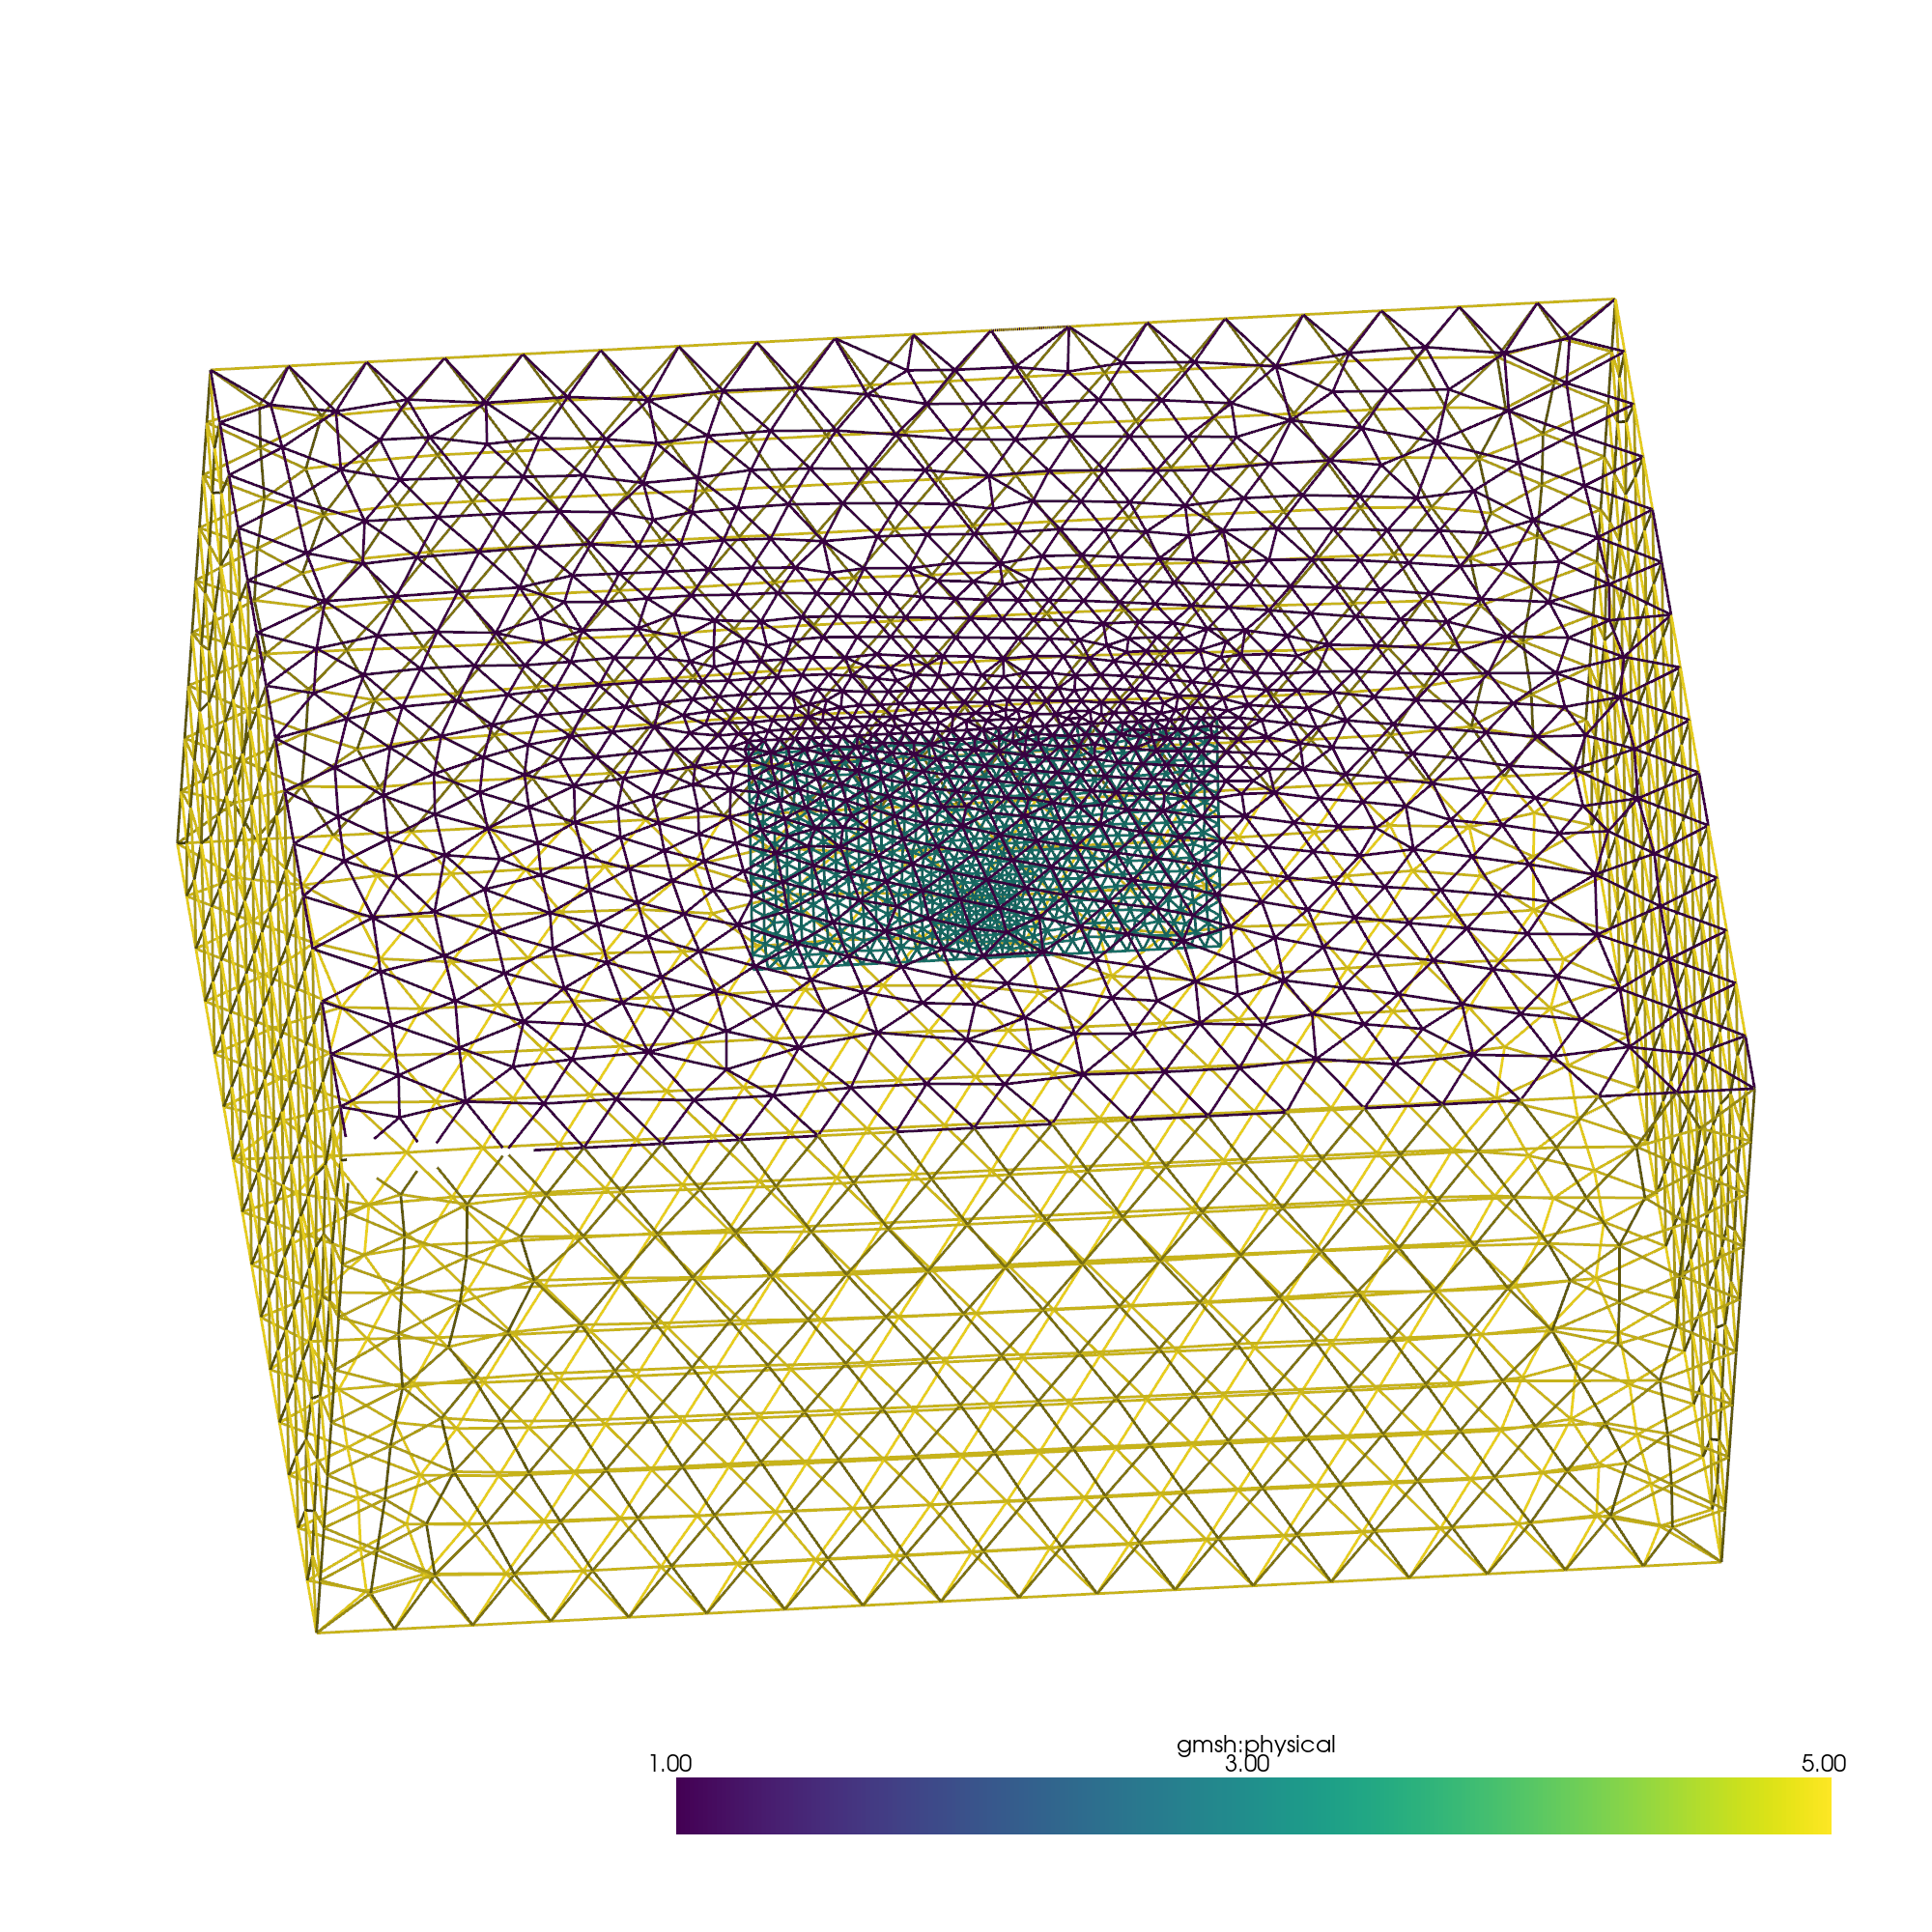

In [46]:
from IPython.display import Image
Image(filename='./tpv12_13_2D.png')

Now let's look at just the fault plane itself using the `threshold()` function. 

In [53]:
fname = "tpv12_13_fault.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 3}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh.threshold(value=(2.5,3.5), scalars="gmsh:physical"), style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)

pl.camera_position = 'xy'
pl.enable_parallel_projection()
pl.screenshot(fname);

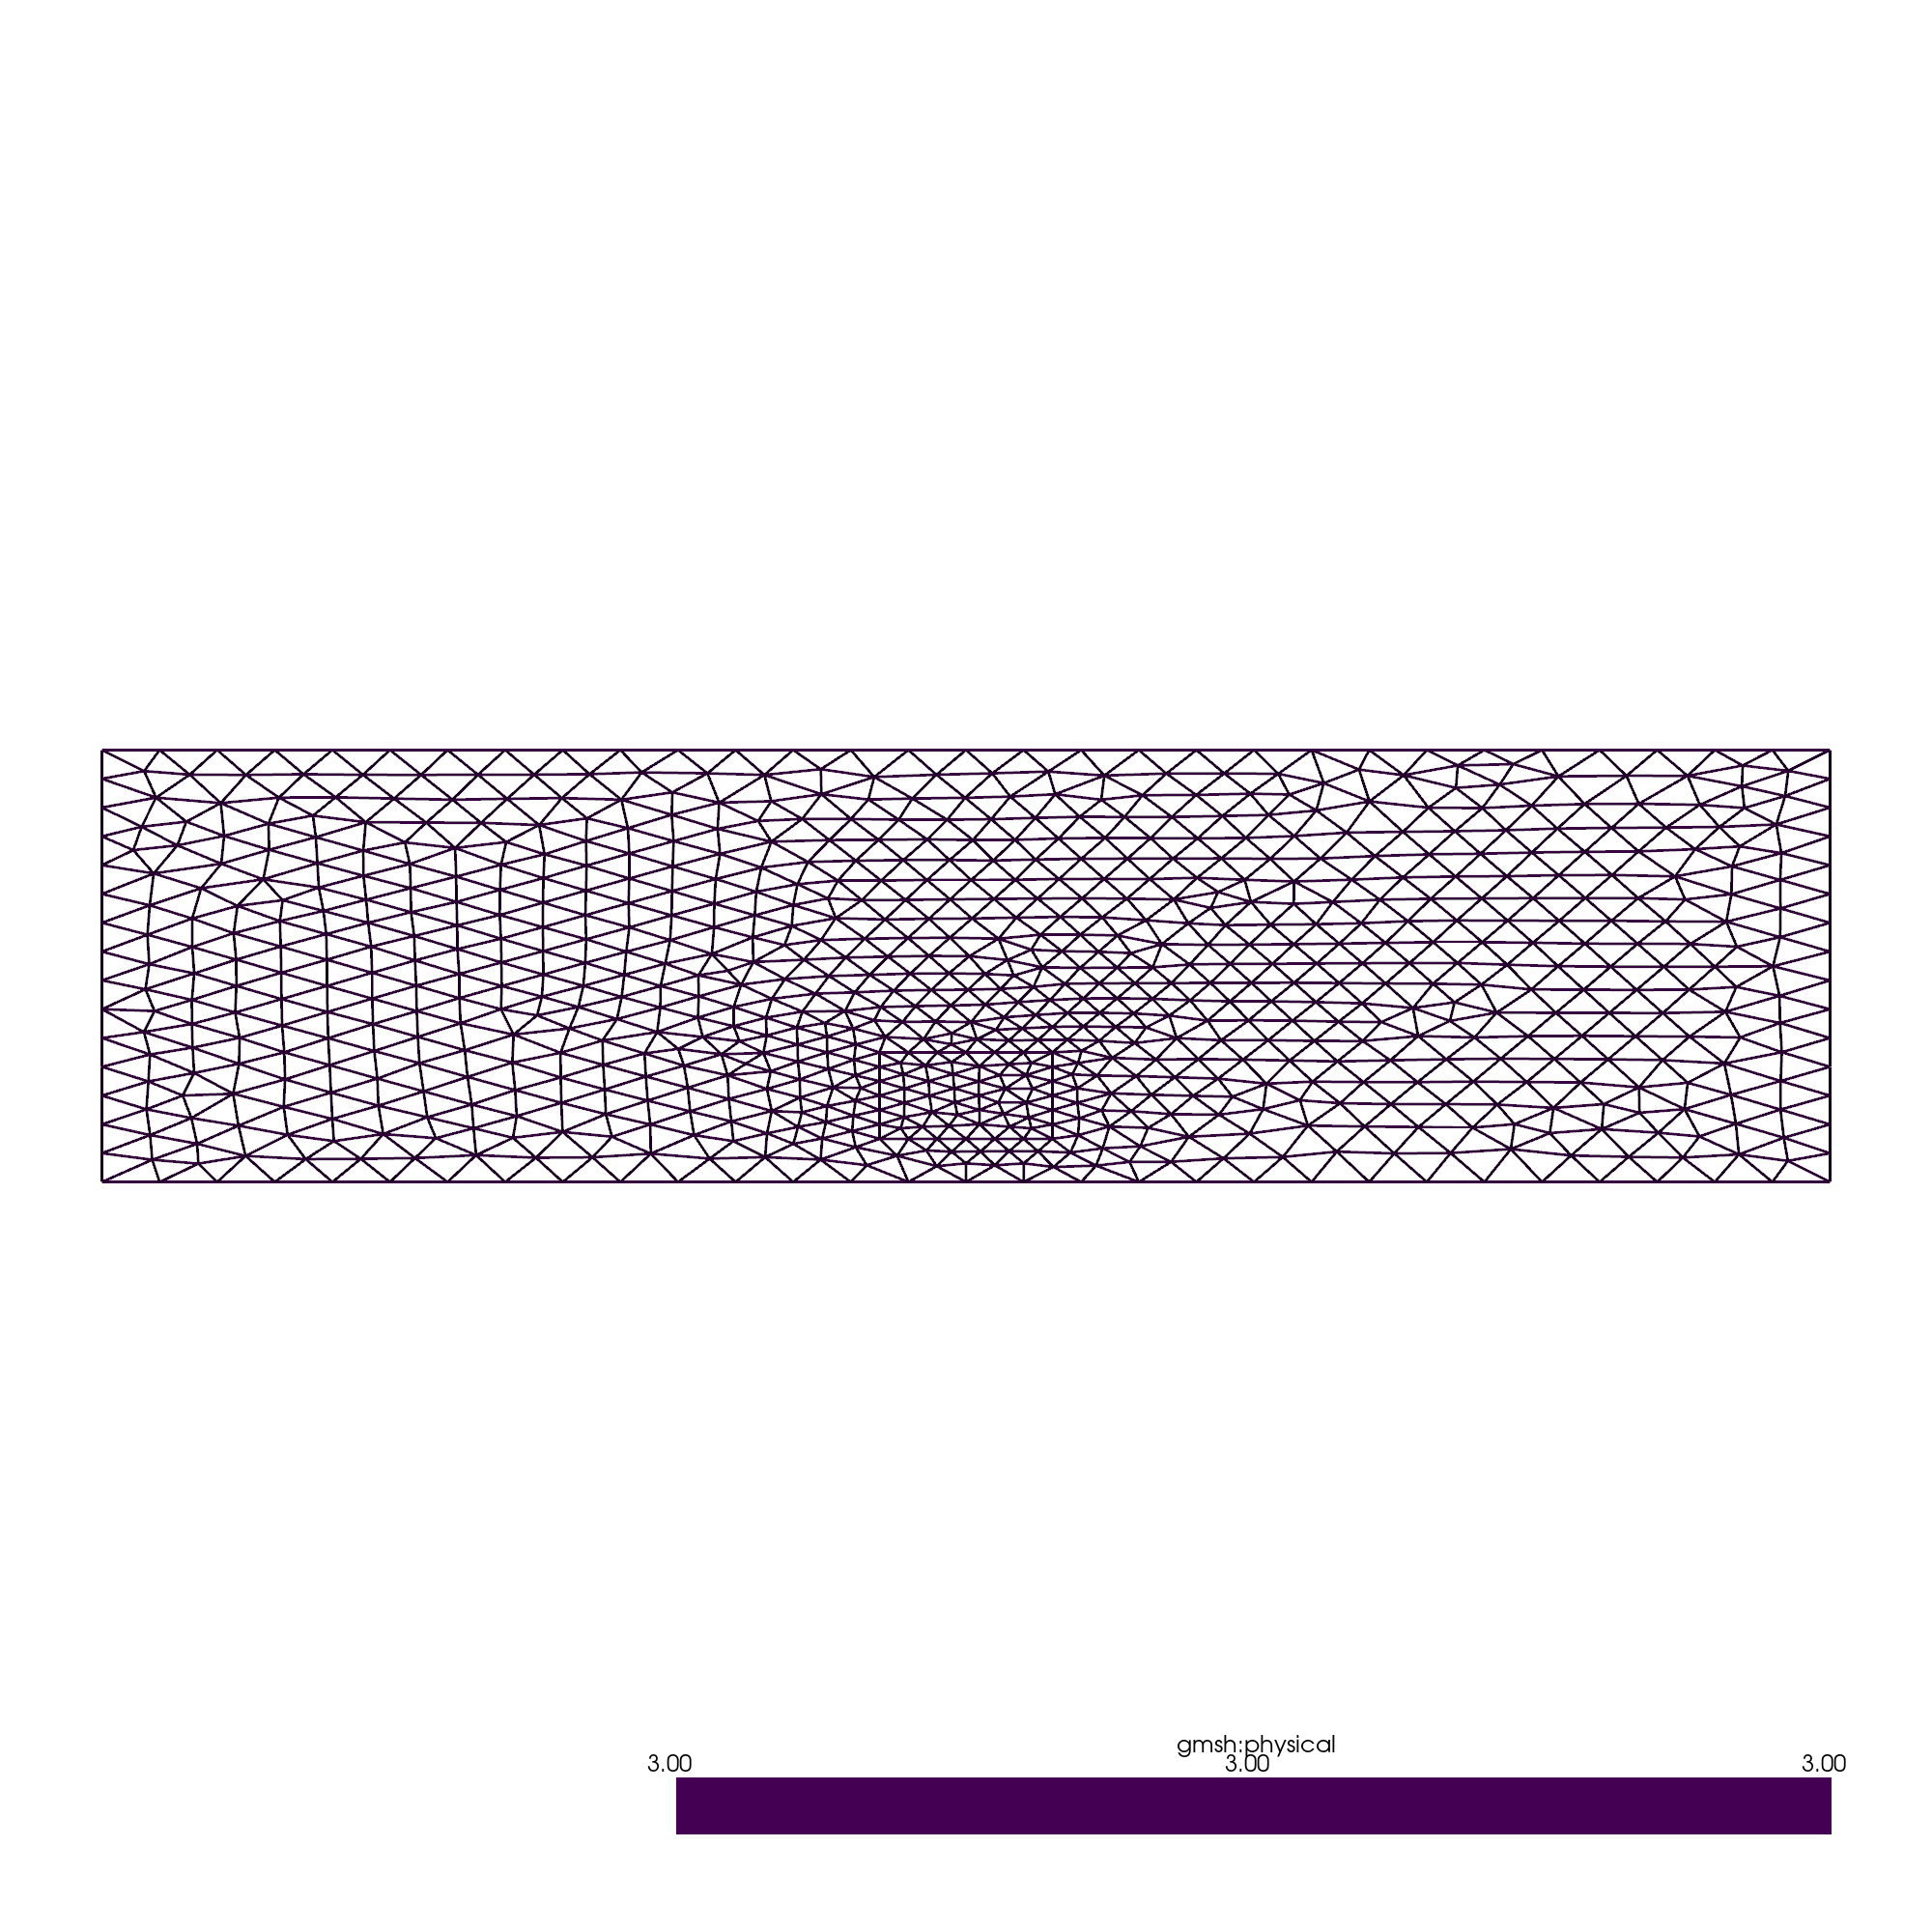

In [54]:
from IPython.display import Image
Image(filename='./tpv12_13_fault.png')

## Demo 3: Generating a complex geometry using the Python GMSH API

In this example, we demonstrate how to leverage the Python GMSH API to mesh a geometry with two intersecting, curved faults. Points defined along the traces of the faults are joined using a spline, which is then extruded at a given dip angle. The intersection of the faults is calculated so it can be exactly meshed. 

We also demonstrate how to use a distance field to locally refine the mesh near the fault. 

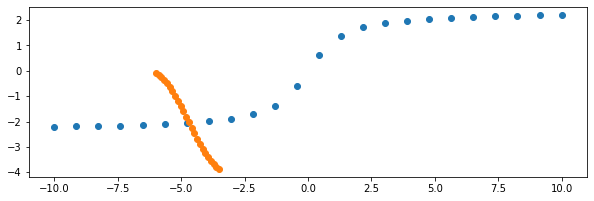

In [4]:
n = 24
xarr_A = np.linspace(-10,10,n)
yarr_A = 1.5 * np.arctan(xarr_A)
trace_A = np.vstack([xarr_A, yarr_A]).T

xarr_B = np.linspace(-6,-3.5,n)
yarr_B = 2.0 * np.cos(xarr_B) - 2.0
trace_B = np.vstack([xarr_B, yarr_B]).T

fig, ax = plt.subplots(figsize=(10,4))
ax.scatter(trace_A[:,0], trace_A[:,1])
ax.scatter(trace_B[:,0], trace_B[:,1])
ax.set_aspect('equal')
plt.show()

In [80]:
h_min = 0.5
h_max = 8.0

In [158]:
gmsh.initialize()

gmsh.model.add("demo3")

In [159]:
eps = 8.0

domain = gmsh.model.occ.addBox(np.min(xarr_A)-eps, np.min(yarr_A)-eps, 0, \
                               np.max(xarr_A)-np.min(xarr_A)+2*eps, np.max(yarr_A)-np.min(yarr_A)+2*eps, -20.0)

In [160]:
trace_A_pts = []
for i in range(trace_A.shape[0]):
    p = gmsh.model.occ.addPoint(trace_A[i,0], trace_A[i,1], 0, h_min)
    trace_A_pts.append(p)

In [161]:
trace_B_pts = []
for i in range(trace_B.shape[0]):
    p = gmsh.model.occ.addPoint(trace_B[i,0], trace_B[i,1], 0, h_min)
    trace_B_pts.append(p)

In [162]:
gmsh.model.occ.synchronize()

We pass the points along each fault trace to the `addSpline()` function which connects them into a smooth curve. 

In [163]:
spline_A = gmsh.model.occ.addSpline(trace_A_pts)
spline_B = gmsh.model.occ.addSpline(trace_B_pts)
gmsh.model.occ.synchronize()

Then we extrude the splines along a vector. This automatically creates surfaces, which we can keep track of by capturing the output of `extrude()`. 

In [164]:
ext_A = gmsh.model.occ.extrude([(1, spline_A)], 0, 5, -8.0)
ext_B = gmsh.model.occ.extrude([(1, spline_B)], 1, 0, -6.0)
gmsh.model.occ.synchronize()

faults = [tag for dim, tag in ext_A + ext_B if dim > 1]
print('Extrusion created faults with tags:', faults)

Extrusion created faults with tags: [7, 8]


The next step is to compute the Boolean fragments of the faults in the volume. 

In [165]:
frag_out = gmsh.model.occ.fragment([(2,s) for s in faults], [(3,1)], removeObject=True, removeTool=True)
gmsh.model.occ.synchronize()

In [166]:
print(frag_out[1])

[[(2, 7)], [(2, 8), (2, 9)], [(3, 1)]]


In [167]:
faults = [7, 8, 9]

We can use a distance field to set a smaller mesh size near the fault. 

In [168]:
dist_T = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(dist_T, "SurfacesList", faults)

threshold_T = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(threshold_T, "InField", dist_T)
gmsh.model.mesh.field.setNumber(threshold_T, "SizeMin", h_min) # Smallest size
gmsh.model.mesh.field.setNumber(threshold_T, "SizeMax", h_max) # Largest size
gmsh.model.mesh.field.setNumber(threshold_T, "DistMin", 2) # Distance from surface
gmsh.model.mesh.field.setNumber(threshold_T, "DistMax", 3)

min_field = gmsh.model.mesh.field.add("Min")
gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", [threshold_T])
gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

Finally, we add physical tagging. These numbers are arbitrary for visualization purposes, and they do not match the SeisSol boundary condition convention. 

In [169]:
gmsh.model.addPhysicalGroup(2, [faults[0]], 3)
gmsh.model.addPhysicalGroup(2, [faults[1]], 4)
gmsh.model.addPhysicalGroup(2, [faults[2]], 5)

gmsh.model.addPhysicalGroup(3, [domain], 1) # volume has physical tag of 1

1

In [170]:
gmsh.model.mesh.generate(3)

gmsh.write("demo3.msh")

gmsh.finalize()

Again, we'll use pyvista to visualize the resulting mesh. 

In [171]:
msh = meshio.read("demo3.msh")
msh.write("demo3.vtu");

mesh = pv.read("demo3.vtu")

Info: VTU format cannot write cell_sets. Converting them to cell_data...

Warning: 1945 cells are not part of any cell set. Using default value -1.

In [181]:
fname = "demo3.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 3}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh, style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)
pl.enable_parallel_projection()
pl.camera_position = 'xy'

pl.camera.azimuth = 10
pl.camera.elevation = 10
# pl.camera.roll += 10
# pl.camera.zoom(0.9)
pl.screenshot(fname);

In [183]:
fname = "demo3_side.png"
sargs = {"title_font_size": 24, "label_font_size": 24, "n_labels": 3}

pl = pv.Plotter(window_size=[2000, 2000], off_screen=True)
pl.add_mesh(mesh, style='wireframe', line_width=3, scalars="gmsh:physical",\
            scalar_bar_args=sargs)
pl.enable_parallel_projection()
pl.camera_position = 'xz'

# pl.camera.azimuth = 10
# pl.camera.elevation = 10
# pl.camera.roll += 10
# pl.camera.zoom(0.9)
pl.screenshot(fname);

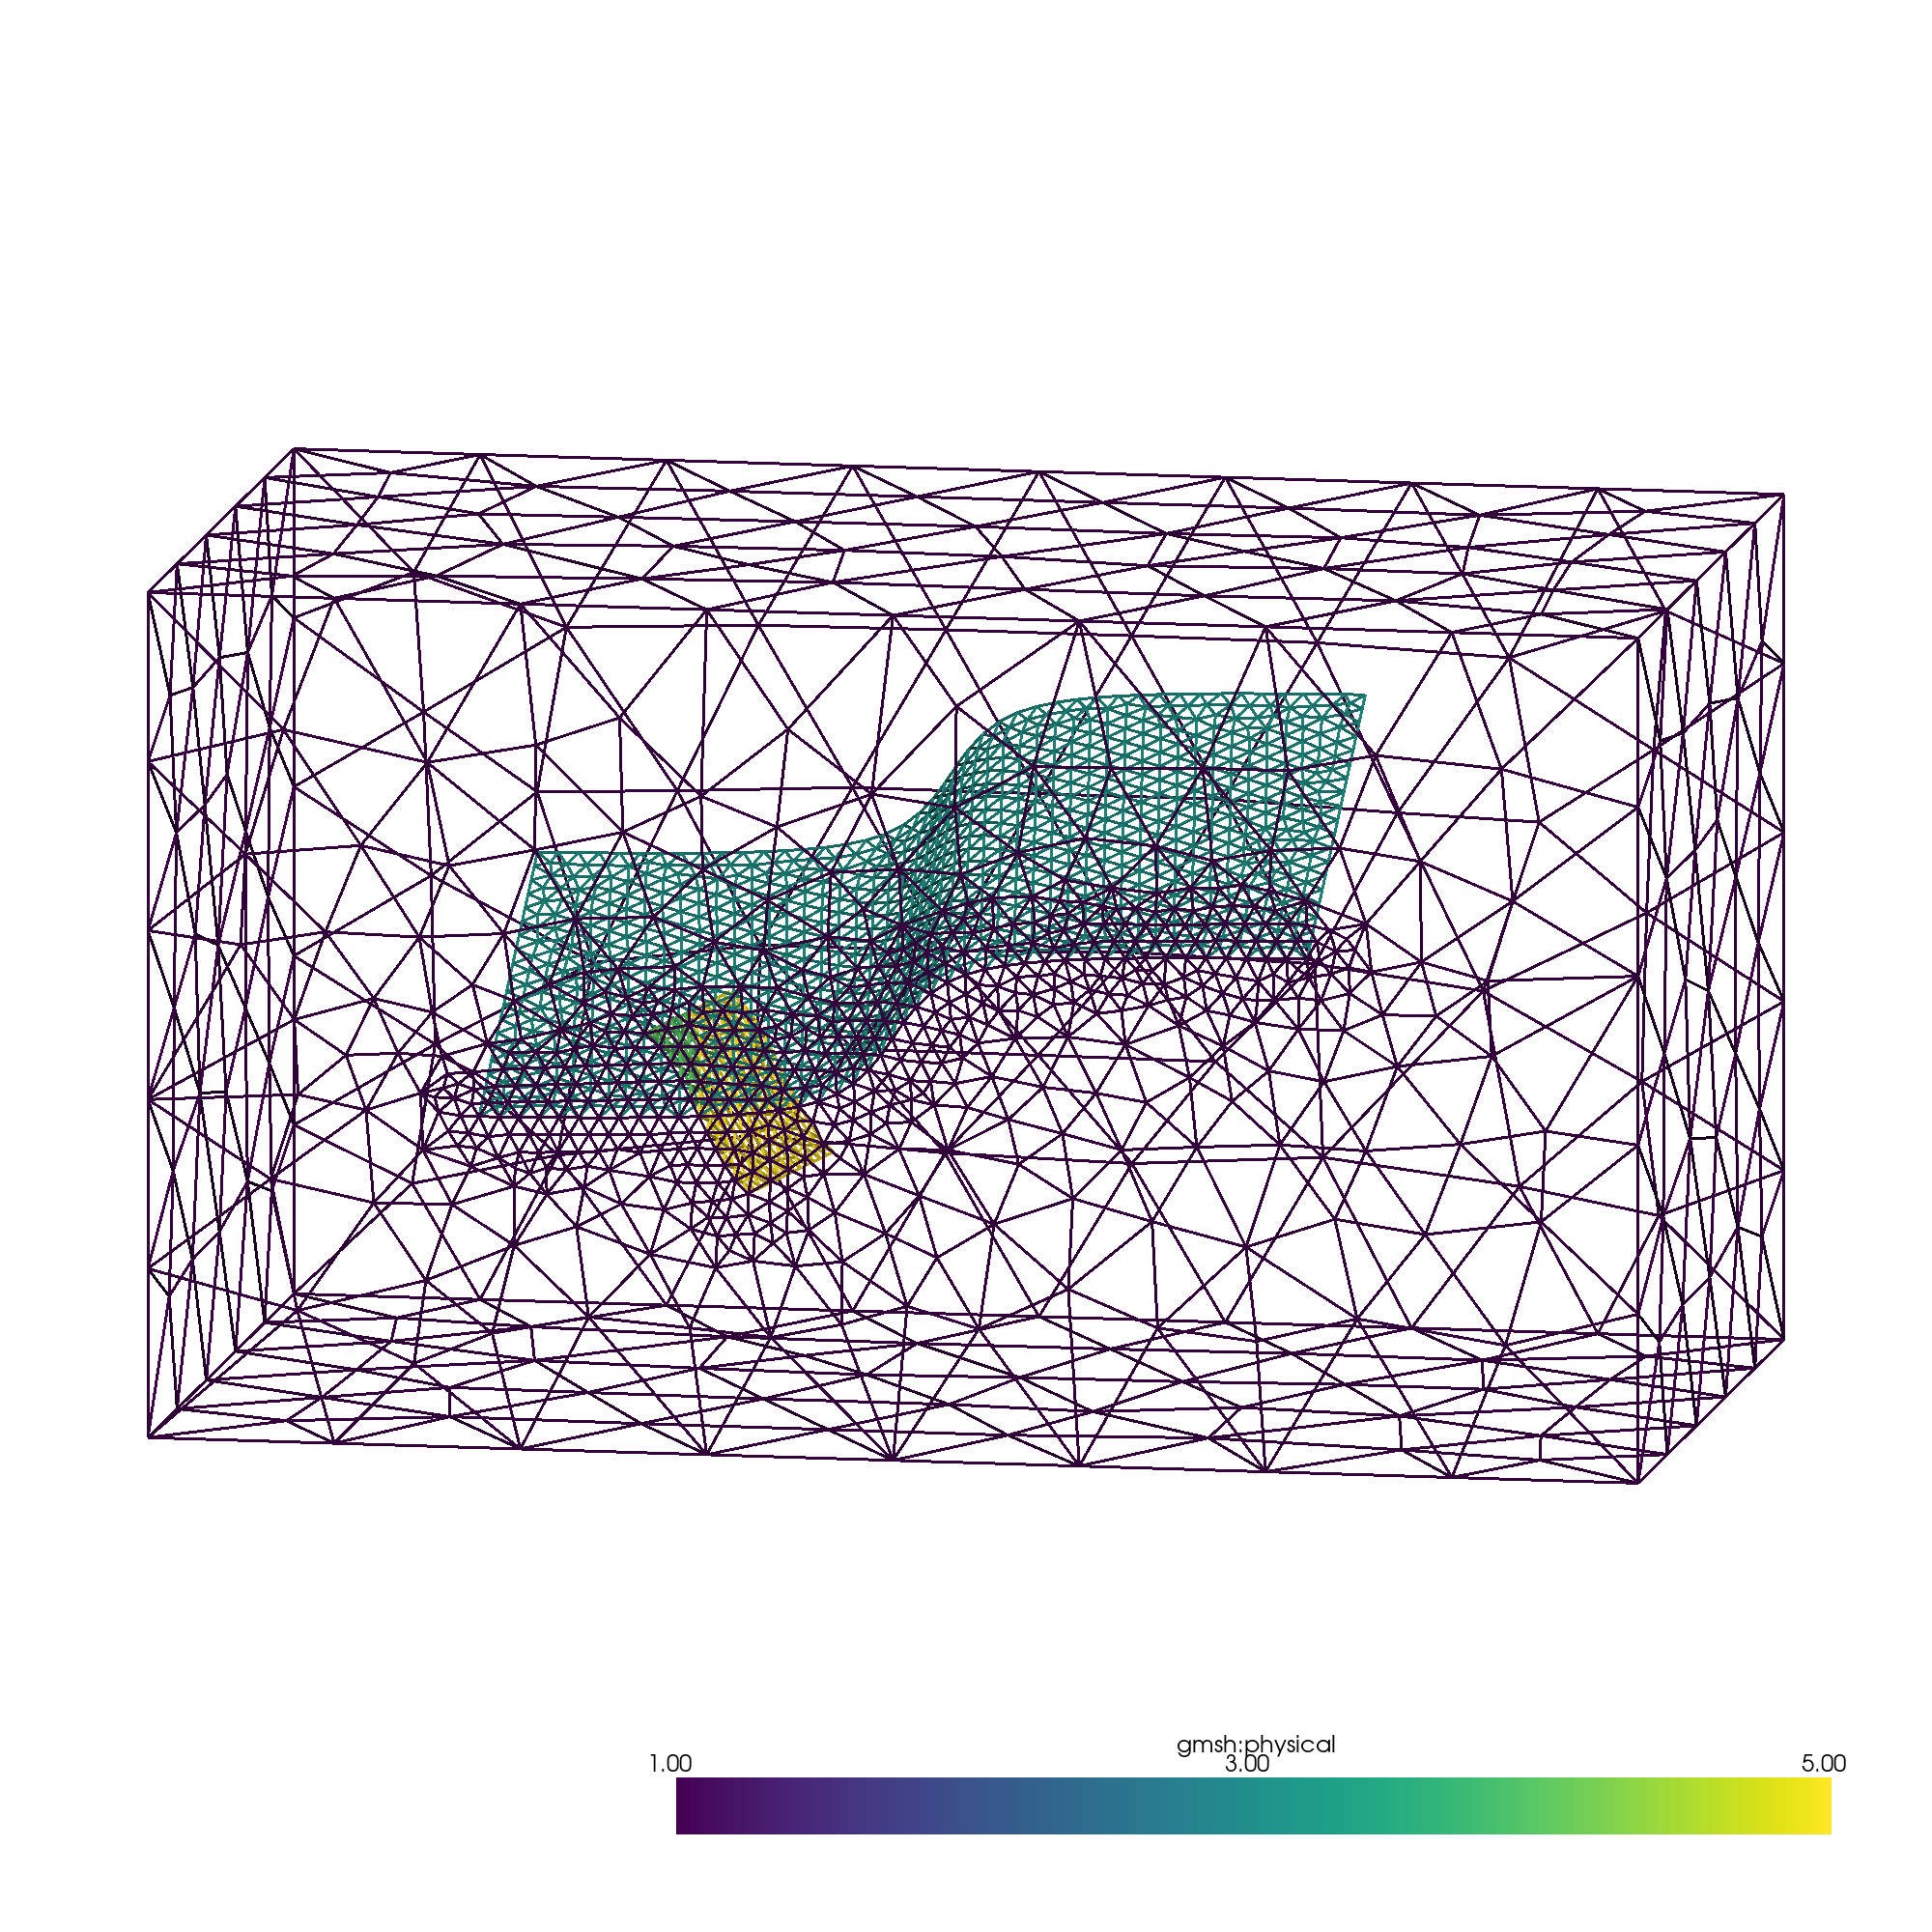

In [182]:
from IPython.display import Image
Image(filename='./demo3.png')

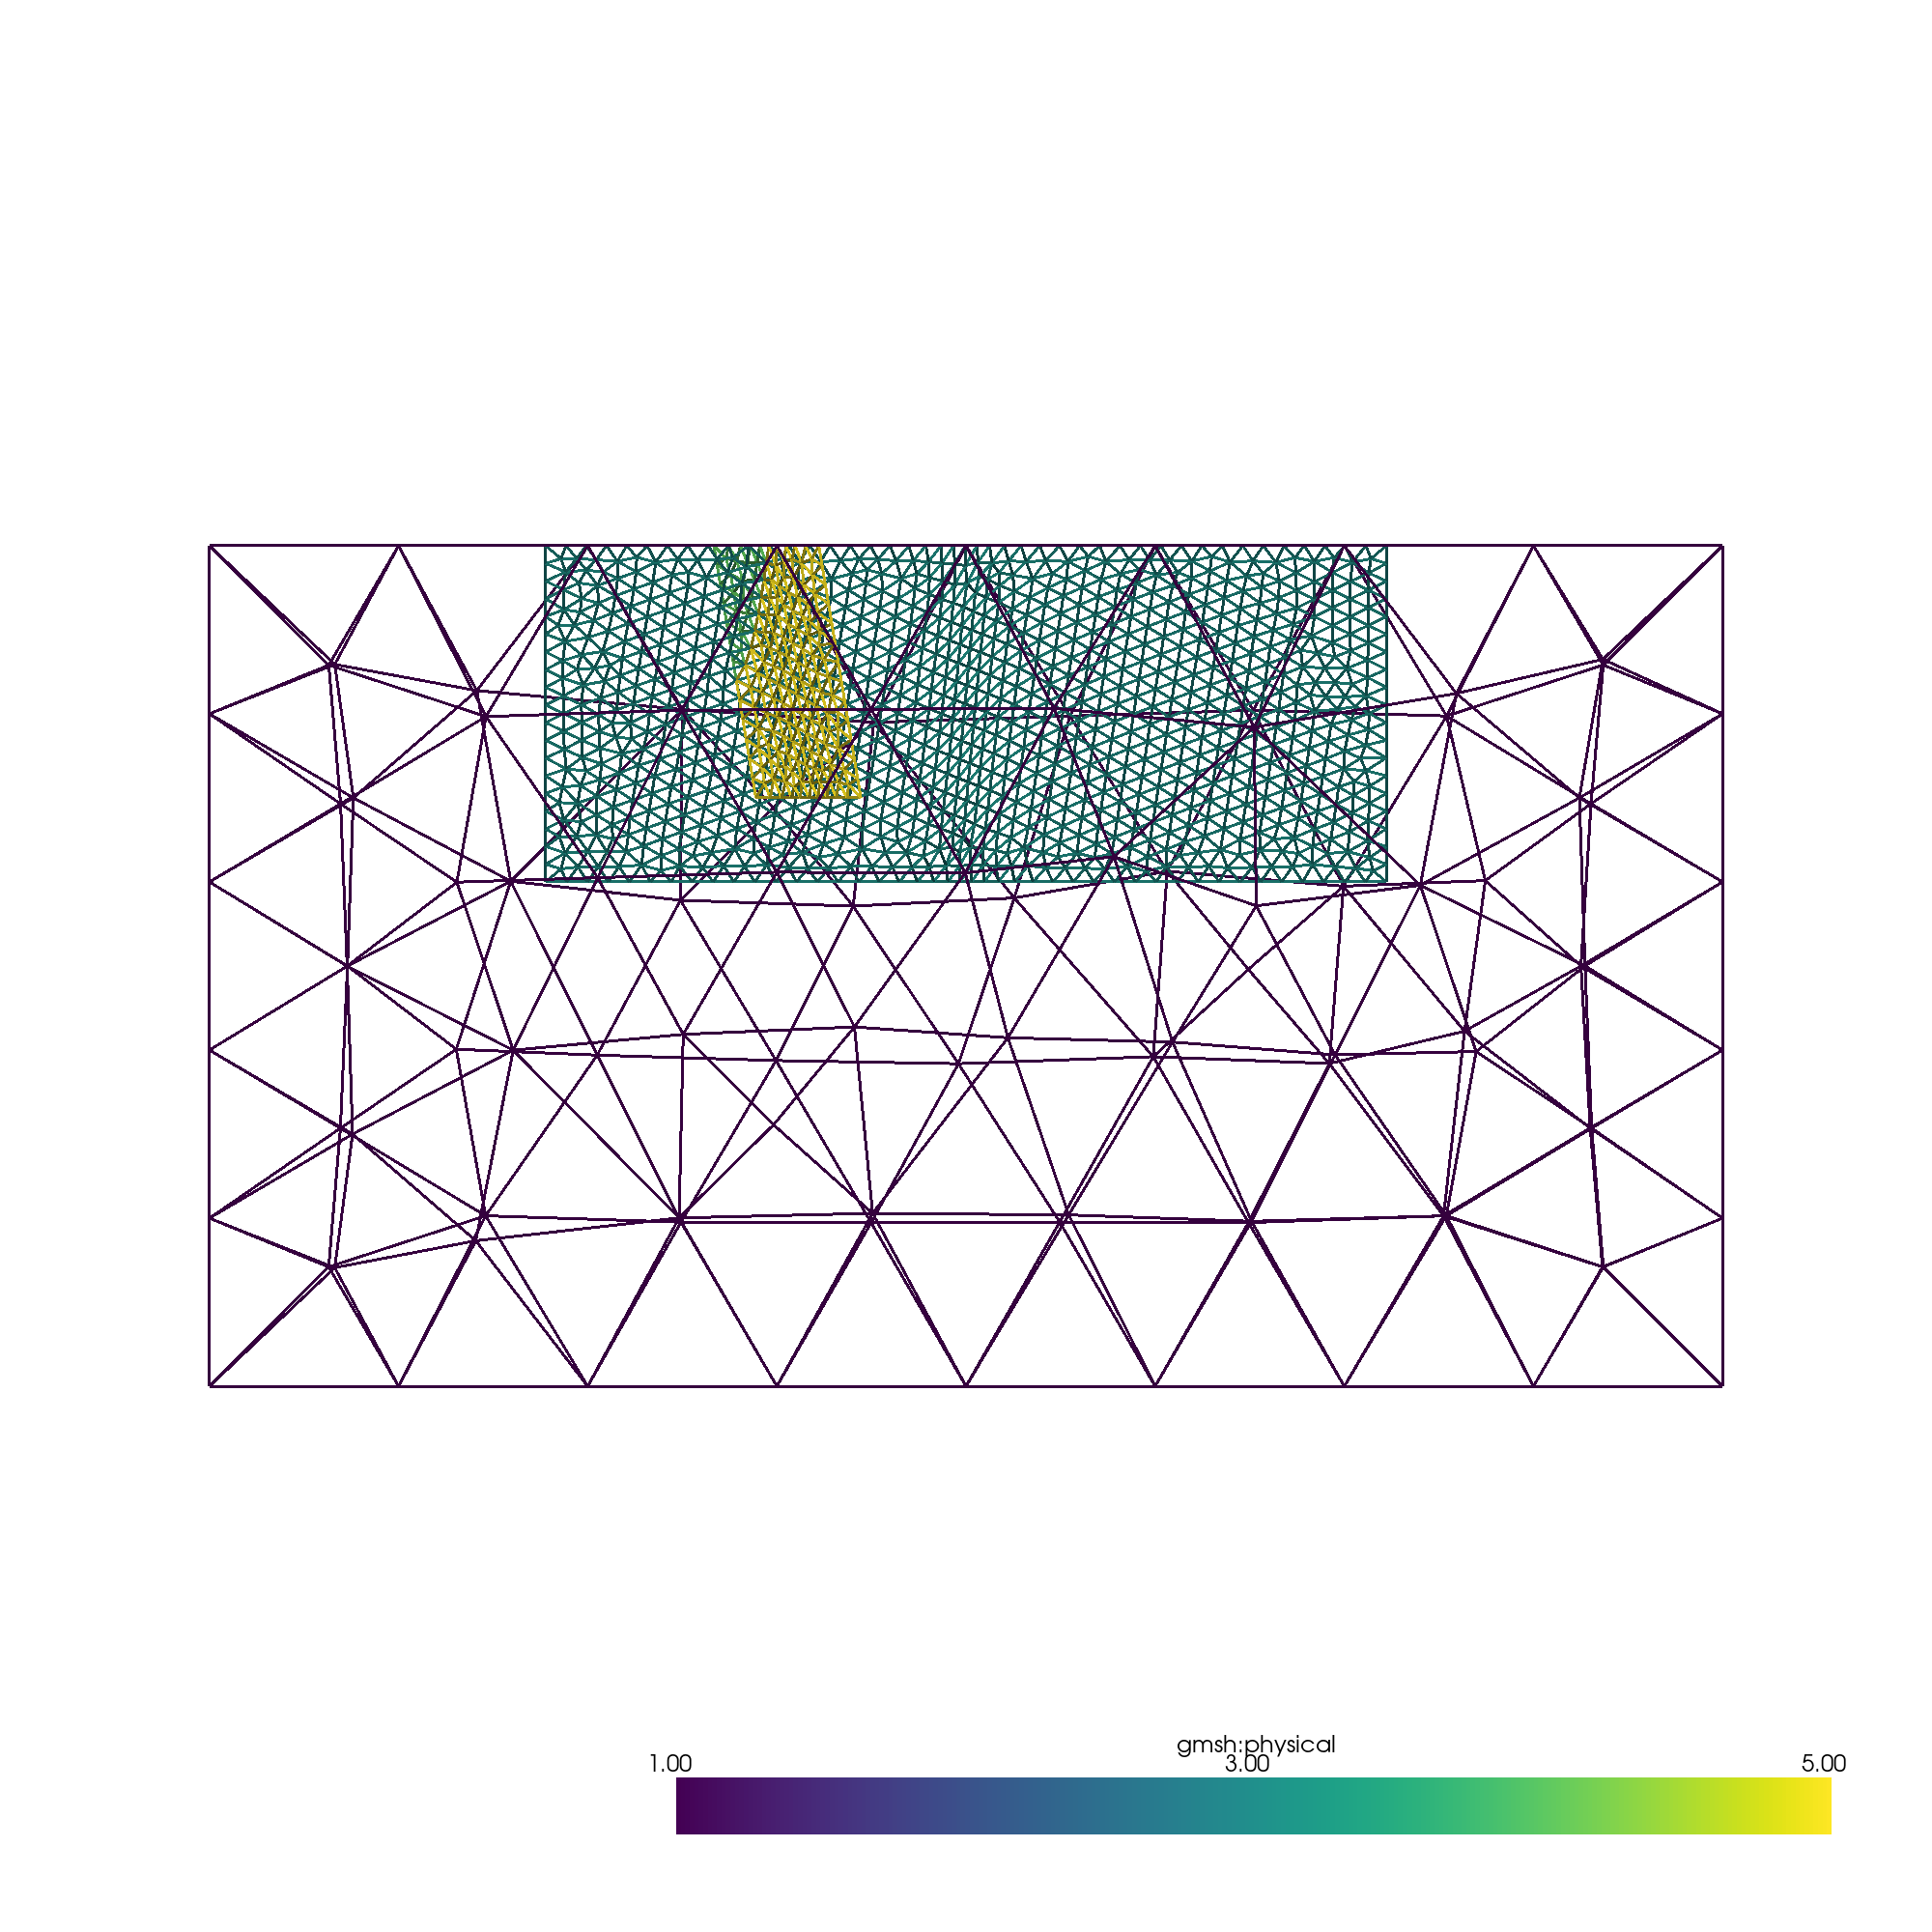

In [184]:
Image(filename='./demo3_side.png')